# AI Engineer Exam


### Assessment Timer
Run the cell below to start the counter.

In [3]:
import time
import base64
import os
from IPython.display import display, HTML

# 1. Download Datasets (Encoded links to discourage direct copying)
links = {
    "cat.jpg": "aHR0cHM6Ly9iYXNlcGF3cy5jb20vX25leHQvaW1hZ2U/dXJsPWh0dHBzJTNBJTJGJTJGaW1hZ2VzLmN0ZmFzc2V0cy5uZXQlMkZxajJ5eHYzOWQ2aWclMkYzQXF4TWszUVdYbXNRM3pZbFhqT2VsJTJGNDBiZGM3Zjg4ZTY5OWYxYTYzZGEyZTMwNjIxMWVmMGElMkZpU3RvY2stNDc0NTQ5Njc4XzYwMHg2MDAuanBnJTNGdyUzRDc1NSUyNmglM0Q3NTUlMjZxJTNEODAmdz0xOTIwJnE9NzU=",
    "mask.jpg": "aHR0cHM6Ly9pLnNzdGF0aWMubmV0LzZCNll1LmpwZw==",
    "shapes.jpg": "aHR0cHM6Ly90aHVtYi5hYy1pbGx1c3QuY29tLzZlLzZlMjZiMWY0NTQxMTI2MzJhYzliNGM4OWMxMWQ4OGVhX3QuanBlZw=="
}

print("Downloading assessment assets...")
for filename, encoded_url in links.items():
    url = base64.b64decode(encoded_url).decode('utf-8')
    # Use quotes to ensure special characters in the URL are handled correctly by the shell
    os.system(f'wget -q -O "{filename}" "{url}"')

# 2. Persistent Timer Logic
def setup_timer():
    display(HTML('''
    <div id="timer-container" style="padding: 10px; background-color: #f0f8ff; border: 1px solid #007bff; border-radius: 5px; position: fixed; top: 10px; right: 10px; z-index: 1000;">
        <strong>Assessment Time:</strong> <span id="timer">00:00:00</span>
    </div>
    <script>
    (function() {
        if (window.assessmentStarted) {
            console.log("Timer already running.");
            return;
        }

        window.assessmentStarted = true;
        let seconds = 0;
        const timerElement = document.getElementById('timer');

        function updateTimer() {
            seconds++;
            const hrs = String(Math.floor(seconds / 3600)).padStart(2, '0');
            const mins = String(Math.floor((seconds % 3600) / 60)).padStart(2, '0');
            const secs = String(seconds % 60).padStart(2, '0');
            timerElement.innerText = `${hrs}:${mins}:${secs}`;
        }

        if (window.timerInterval) clearInterval(window.timerInterval);
        window.timerInterval = setInterval(updateTimer, 1000);
    })();
    </script>
    '''))

setup_timer()
print("Setup complete. Timer is active.")

Setup complete. Timer is active.


## 1. Basic NumPy Manipulation & Image Processing

### 1.1 Crop Image with Mask

**Instruction :** Given a grayscale image (cat.jpg) and a binary mask (mask.jpg).

1. Load the image and mask using NumPy.
2. Apply the mask to the image, setting all masked-out regions to 0 and mask regions to 1.
3. Apply with some operation to crop the image with mask region
3. Display the masked image using Matplotlib.

ref : https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_gui/py_image_display/py_image_display.html

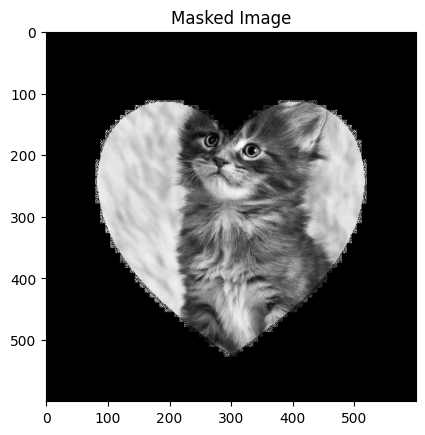

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('cat.jpg', 0)
mask = cv2.imread('mask.jpg', 0)

mask = np.where(mask > 0, 1, 0).astype(np.uint8)

masked_image = image * mask

plt.imshow(masked_image, cmap='gray')
plt.title('Masked Image')
plt.show()



### 1.2 Image Transformation

**Instruction :** Given the image. You must horizontally flip the image.

**Any image transformation library is not allowed**

1. Load the image
2. Horizontally flip the image

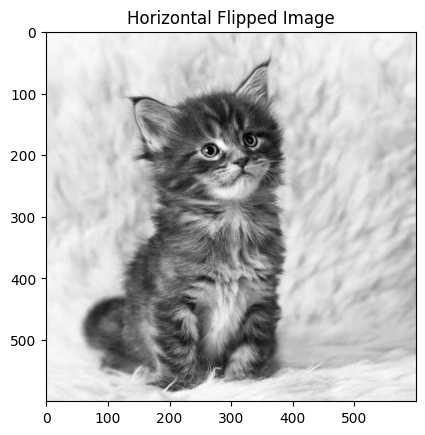

In [12]:
image = cv2.imread('cat.jpg', 0)
h_flipped_image = image[:, ::-1]

plt.imshow(h_flipped_image, cmap='gray')
plt.title('Horizontal Flipped Image')
plt.show()

### 1.3 (Bonus) Count Distinct Object in the Image

**Instruction :** You are given an image containing multiple distinct objects (like in the attached screenshot). Your task is to count the number of distinct objects using OpenCV and NumPy.


1. Load the image and convert to grayscale
2. Convert the image grayscale
3. Convert to a binary format using thresholding.
4. Use cv2.findContours() to detect objects in the binary image.
5. Count and return the number of distinct objects.
6. Display the image with contours drawn around each detected object.

ref : https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

https://docs.opencv.org/3.4/d4/d73/tutorial_py_contours_begin.html

Number of distinct objects: 6


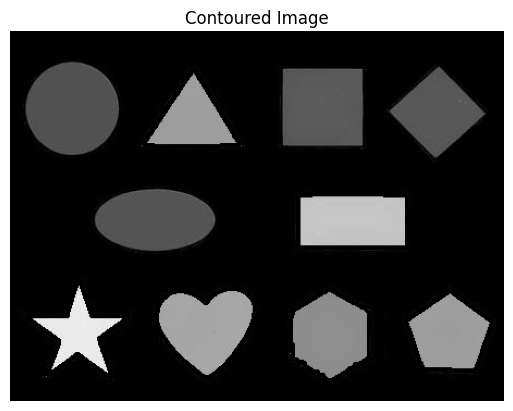

In [13]:
image = cv2.imread('shapes.jpg', 0)
gray_image = image
_, thresh = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

object_count = len(contours)
print(f"Number of distinct objects: {object_count}")

for c in contours:
  cv2.drawContours(image, [c], -1, (0, 255, 255), 2)

plt.imshow(image, cmap='gray')
plt.title('Contoured Image')
plt.axis('off')
plt.show()

## 2. Basic Text Processing


### 2.1 Redacting Personal Information

**Instruction :** Given the following text

1.   Design a regular expression to replace IDs with \<REDACTED>
2.   Output should return

This is a sample text with ID numbers: นี่คือข้อมูลสำคัญที่ไม่ควรถูกเปิดเผย 1234 เริ่ม เลขบัตรประชาชน \<REDACTED> และ \<REDACTED>

ref : https://docs.python.org/3/library/re.html




In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # Use adaptive pooling so the classifier is input-size agnostic
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)          
        x = torch.flatten(x, 1)         
        logits = self.classifier(x)     
        return logits

model = SimpleCNN(num_classes=4)
dummy_input = torch.randn(2, 3, 64, 64)
output = model(dummy_input)
print("output shape:", output.shape)

In [15]:
import re

text = """
This is a sample text with ID numbers: นี่คือข้อมูลสำคัญที่ไม่ควรถูกเปิดเผย 1234 เริ่ม เลขบัตรประชาชน 1105267819254 และ 1-2345-67890-12-3
"""

# RE to match sequences of digits, including those with dashes and numbers
pattern = r'\d+(?:-\d+)*'

masked_text = re.sub(pattern, '<REDACTED>', text)

print(masked_text)


This is a sample text with ID numbers: นี่คือข้อมูลสำคัญที่ไม่ควรถูกเปิดเผย <REDACTED> เริ่ม เลขบัตรประชาชน <REDACTED> และ <REDACTED>



## 3. Basic Deep Learning Knowledge


## 3.1 - Simple CNN Construction using PyTorch

Given a convolutional neural network with the following architecture:

1. Conv2D Layer: 3 input channels, 16 output channels, 3×3 kernel, stride=1, padding=1
2. ReLU Activation
3. MaxPool2D Layer: 2×2 kernel, stride=2
4. Conv2D Layer: 16 input channels, 32 output channels, 3×3 kernel, stride=1, padding=1
5. ReLU Activation
6. MaxPool2D Layer: 2×2 kernel, stride=2
7. Fully Connected Layer with 4 logits

Contruct a CNN with PyTorch

ref : https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 64 * 64, 4)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x

dummy_input = torch.randn(1, 3, 256, 256)
model = SimpleCNN()
output = model(dummy_input)
print(output.shape)  # torch.Size([1, 4])

torch.Size([1, 4])


# 3.2 Basic Hyperparameter Tuning (10 pt)

**Question :** If the loss oscillates wildly as shown in the figure, which hyperparameter should be adjusted first?

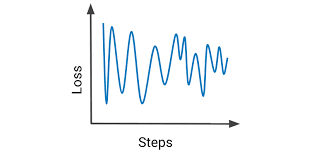

**Answer :**

ต้องมีการปรับ Learning Rate ก่อน เนื่องจากมีค่าสูงเกินไป ทำให้ค่า Loss มีค่าแกว่งและไม่ลู่เข้าแบบปกติ ซึ่งเปรียบเสมือนการลู่เข้า Global minimum แต่ Loss กระโดดไปมา ทำให้ลู่เข้าช้าและไม่คงที่ (จริงๆ แอบคิดว่ามันคล้ายๆ SGD นะครับ แต่ว่ามันเยอะเกินไปหน่อย โดยปกติ SGD เอาไว้แก้ป้ญหา Local minimum)

## 4. LLM & Gen-AI Application

---

### **Requirement**

Conceptualize and develop an innovative AI Product or Solution tailored for **True Digital Group** and **True Corp**.

### **Objective**

Introduce a novel **Solution Capability** that drives strategic value, enhances the existing ecosystem, or addresses untapped market opportunities for the organization.

### **Evaluation Criteria**

Your submission will be rigorously evaluated based on the following matrix (Total: 100 points):

* **Creativity & Innovation (20 pts):** Originality of the concept and its uniqueness in solving the identified problem.
* **Business Impact & ROI (35 pts):** Viability of the business case, market relevance, and potential to drive revenue or operational efficiency for True.
* **Code Quality & Engineering Best Practices (25 pts):** Clean, modular, well-documented, and production-ready code.
* **AI Technique & Architectural Scalability (20 pts):** Sophistication and appropriateness of the chosen AI/ML models, along with the system's capacity to scale under production workloads.

---

### **Execution & Submission Guidelines**

* **Development Flexibility:** If coding directly within Google Colab is restrictive, you are encouraged to build a structured repository on **GitHub**. You can then clone and execute your repository within the Colab notebook to demonstrate functionality, evaluation metrics, and live inference.
* **Critical Guardrail:** Ensure that the notebook executes seamlessly from end to end. **Inability to run the code will result in an automatic score of 0 points**, with no opportunity for re-submission or follow-up clarification.

---

### Quick Tips for Submission:

* **Architecture:** Instead of just a raw script, organize your GitHub repo with a clear structure (e.g., `src/`, `config/`, `tests/`, `README.md`).
* **Production Mindset:** Briefly mention how this solution would be deployed (e.g., API endpoints, CI/CD, or cloud data pipelines) within your notebook documentation to secure those scalability points.

GitHub : 

### **Best of Luck!**

> This assessment is your platform to showcase how engineering excellence meets business vision. Treat this notebook not just as a test, but as a blueprint for a production-ready system. We are excited to see your architectural choices, your code craftsmanship, and the strategic impact of your AI solution.
> **Happy Coding!**